
# PyTorch Multilayer Perceptron (MLP) Tutorial

This notebook will guide you through building and training a simple **Multilayer Perceptron (MLP)** in PyTorch.
We'll use a toy dataset (`make_moons`) for visualization and understanding.


In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np


## 1 Create a Toy Dataset

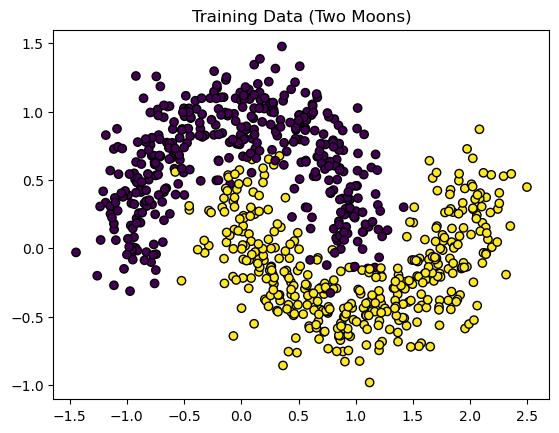

In [2]:

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='viridis', edgecolor='k')
plt.title('Training Data (Two Moons)')
plt.show()


## 2 Define the MLP Model

In [3]:

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.layers(x)

model = MLP(input_dim=2, hidden_dim=16, output_dim=2)
print(model)


MLP(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)


## 3 Define Loss Function and Optimizer

In [4]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


## 4 Train the Model

In [15]:

epochs = 100
for epoch in range(epochs):
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 0.2584
Epoch [20/100], Loss: 0.2584
Epoch [30/100], Loss: 0.2584
Epoch [40/100], Loss: 0.2584
Epoch [50/100], Loss: 0.2584
Epoch [60/100], Loss: 0.2584
Epoch [70/100], Loss: 0.2584
Epoch [80/100], Loss: 0.2584
Epoch [90/100], Loss: 0.2584
Epoch [100/100], Loss: 0.2584


## 5 Evaluate Model Accuracy

In [16]:

with torch.no_grad():
    preds = model(X_test)
    predicted = torch.argmax(preds, dim=1)
    acc = (predicted == y_test).float().mean()
    print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.8800


## 6 Visualize Decision Boundary

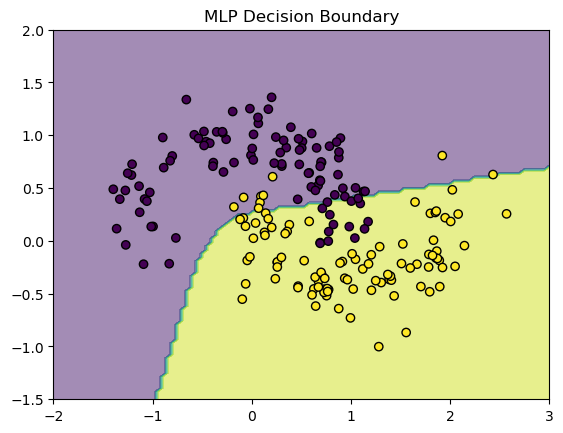

In [7]:

xx, yy = np.meshgrid(np.linspace(-2, 3, 100), np.linspace(-1.5, 2, 100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = torch.argmax(model(grid), dim=1).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5, cmap='viridis')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, edgecolor='k')
plt.title("MLP Decision Boundary")
plt.show()


## Exercises

### Exercise 1
Modify the MLP to have **two hidden layers** with dimensions `[16, 8]` and ReLU activations.


In [10]:
class MLP_two_hidden(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP_two_hidden, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, output_dim)
        )
        
    def forward(self, x):
        return self.layer(x)
    
model_two_hidden = MLP_two_hidden(input_dim=2, output_dim=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_two_hidden.parameters(), lr=0.01)

epochs = 100
for epoch in range(epochs):
    outputs = model_two_hidden(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.5619
Epoch [20/100], Loss: 0.4275
Epoch [30/100], Loss: 0.3250
Epoch [40/100], Loss: 0.2714
Epoch [50/100], Loss: 0.2541
Epoch [60/100], Loss: 0.2298
Epoch [70/100], Loss: 0.2012
Epoch [80/100], Loss: 0.1695
Epoch [90/100], Loss: 0.1404
Epoch [100/100], Loss: 0.1176


In [11]:
with torch.no_grad():
    preds = model_two_hidden(X_test)
    predicted = torch.argmax(preds, dim=1)
    acc = (predicted == y_test).float().mean()
    print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.9750


### Exercise 2
Try replacing `ReLU` with `nn.Tanh()`. How does accuracy change?

In [13]:
class MLP_Tanh(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP_Tanh, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.layer(x)
    
model_tanh = MLP_Tanh(input_dim=2, hidden_dim=16, output_dim=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tanh.parameters(), lr=0.01)

epochs = 100
for epoch in range(epochs):
    outputs = model_tanh(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.4500
Epoch [20/100], Loss: 0.3512
Epoch [30/100], Loss: 0.3137
Epoch [40/100], Loss: 0.2948
Epoch [50/100], Loss: 0.2919
Epoch [60/100], Loss: 0.2899
Epoch [70/100], Loss: 0.2885
Epoch [80/100], Loss: 0.2865
Epoch [90/100], Loss: 0.2840
Epoch [100/100], Loss: 0.2802


In [14]:
with torch.no_grad():
    preds = model_tanh(X_test)
    predicted = torch.argmax(preds, dim=1)
    acc = (predicted == y_test).float().mean()
    print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.8700


### Exercise 3
Add **L2 regularization (weight decay)** to the optimizer and observe its effect.

In [17]:
class MLP_L2(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP_L2, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.layer(x)
    
model_L2 = MLP_L2(input_dim=2, hidden_dim=16, output_dim=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_L2.parameters(), lr=0.01, weight_decay=1e-4)

epochs = 100
for epoch in range(epochs):
    outputs = model_L2(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.5259
Epoch [20/100], Loss: 0.3915
Epoch [30/100], Loss: 0.3193
Epoch [40/100], Loss: 0.2876
Epoch [50/100], Loss: 0.2690
Epoch [60/100], Loss: 0.2573
Epoch [70/100], Loss: 0.2472
Epoch [80/100], Loss: 0.2375
Epoch [90/100], Loss: 0.2273
Epoch [100/100], Loss: 0.2168


In [19]:
with torch.no_grad():
    preds = model_L2(X_test)
    predicted = torch.argmax(preds, dim=1)
    acc = (predicted == y_test).float().mean()
    print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.9150
